In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tempfile

# ==========================================
# 0. Environment and Path Configuration
# ==========================================
# Defining a temporary directory for solver files to avoid permission issues
safe_temp_dir = r"D:\PyPSA_Temp" 

if not os.path.exists(safe_temp_dir):
    os.makedirs(safe_temp_dir)

os.environ['TMPDIR'] = safe_temp_dir
os.environ['TEMP'] = safe_temp_dir
os.environ['TMP'] = safe_temp_dir
tempfile.tempdir = safe_temp_dir

script_dir = os.getcwd() 
os.chdir(script_dir)

# ==========================================
# 1. Initialize Network and Snapshots
# ==========================================
n = pypsa.Network()

# Hourly snapshots for a full year (8760 hours)
snapshots = pd.date_range("2017-01-01 00:00", "2017-12-31 23:00", freq="H")
n.set_snapshots(snapshots)

# ==========================================
# 2. Build Multi-node Topology (Buses)
# ==========================================
countries = ["DE", "FR", "AT", "CH"]

# Add buses with a nominal voltage of 400 kV
for c in countries:
    n.add("Bus", c, v_nom=400)

# ==========================================
# 3. Add Interconnectors (HVAC Lines)
# ==========================================
interconnectors = {
    "AT-CH": {"bus0": "AT", "bus1": "CH", "s_nom": 2152.75},
    "AT-DE": {"bus0": "AT", "bus1": "DE", "s_nom": 4232.10},
    "CH-DE": {"bus0": "CH", "bus1": "DE", "s_nom": 7106.32},
    "CH-FR": {"bus0": "CH", "bus1": "FR", "s_nom": 2926.94},
    "DE-FR": {"bus0": "DE", "bus1": "FR", "s_nom": 4120.00}
}

for name, params in interconnectors.items():
    n.add("Line", name,
          bus0=params["bus0"],
          bus1=params["bus1"],
          s_nom=params["s_nom"],           # Fixed interconnection capacity
          s_nom_extendable=False,          # Disable capacity expansion for cross-border lines
          x=0.1)                           # Key parameter: Per-unit reactance

# ==========================================
# 4. Generator Configuration for Joint Optimization
# ==========================================
country_techs = {
    "DE": ["Wind Onshore", "Solar", "Fossil Hard coal", "Fossil Gas"], 
    "FR": ["Wind Onshore", "Solar", "Fossil Gas", "Nuclear"],
    "CH": ["Wind Onshore", "Solar", "Hydro Run-of-river and pondage", "Hydro Water Reservoir", "Hydro Pumped Storage"],
    "AT": ["Wind Onshore", "Solar", "Fossil Gas", "Hydro Run-of-river and pondage", "Hydro Water Reservoir", "Hydro Pumped Storage"]
}

costs = {
    "Wind Onshore": {"capital_cost": 103363.0, "marginal_cost": 0.01},
    "Solar": {"capital_cost": 49219.0, "marginal_cost": 0.01},
    "Fossil Gas": {"capital_cost": 66534.0, "marginal_cost": 55.38},      
    "Hydro Run-of-river and pondage": {"capital_cost": 270930.0, "marginal_cost": 0.01},
    "Hydro Water Reservoir": {"capital_cost": 160620.0, "marginal_cost": 0.01},
    "Fossil Hard coal": {"capital_cost": 135000.0, "marginal_cost": 40.0},
    "Nuclear": {"capital_cost": 450000.0, "marginal_cost": 12.0},
    "Hydro Pumped Storage": {"capital_cost": 160000.0, "marginal_cost": 2.0}
}

# List of Variable Renewable Energy Sources (VRES) requiring availability profiles (p_max_pu)
vres_techs = ["Wind Onshore", "Solar", "Hydro Run-of-river and pondage"]

C:\Users\高辛烨赫\AppData\Local\Temp\ipykernel_6748\1975416036.py:31: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [2]:
def clean_datetime_index(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        time_str = df.index.astype(str)
        # Handle time interval formats containing " - " (e.g., "00:00 - 01:00")
        if time_str.str.contains(' - ').any():
            time_str = time_str.str.split(' - ').str[0]
        # Remove timezone suffixes like " (CET)" or " (CEST)"
        time_str = time_str.str.replace(r'\s*\(.*?\)', '', regex=True)
        # Force parsing using "Day/Month/Year" format
        df.index = pd.to_datetime(time_str, dayfirst=True)
    return df

# Iterate through countries to populate data
for c in countries:
    # 1. Import and process load data
    df_path = os.path.join(script_dir, f"{c}_Load_d).csv") # Ensure filename matches local file naming convention
    load_df = pd.read_csv(df_path, index_col=0)
    load_df = clean_datetime_index(load_df)
    
    # Clean numeric format (remove commas and convert to float)
    load_series = load_df['Actual Total Load (MW)'].astype(str).str.replace(',', '')
    load_series = pd.to_numeric(load_series, errors='coerce')

    # Resample to hourly and align with network snapshots
    hourly_load = load_series.resample('1h').mean()
    hourly_load = hourly_load.reindex(n.snapshots).fillna(0) 

    n.add("Load", f"{c}_load",
          bus=c,
          p_set=hourly_load.values)
    
    # 2. Import generation data and convert to generator units
    df_path = os.path.join(script_dir, f"{c}_Gene_d).csv")
    gene_df = pd.read_csv(df_path, index_col=0) 
    gene_df = clean_datetime_index(gene_df)
    
    for tech in country_techs[c]:
        cost = costs[tech]
        
        tech_df = gene_df[gene_df['Production Type'] == tech]

D:\PyPSA_Temp\ipykernel_6748\1984804814.py:34: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.



In [3]:
def clean_datetime_index(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        time_str = df.index.astype(str)
        # Handle time interval formats containing " - " (e.g., "00:00 - 01:00")
        if time_str.str.contains(' - ').any():
            time_str = time_str.str.split(' - ').str[0]
        # Remove timezone suffixes like " (CET)" or " (CEST)"
        time_str = time_str.str.replace(r'\s*\(.*?\)', '', regex=True)
        # Force parsing using "Day/Month/Year" format
        df.index = pd.to_datetime(time_str, dayfirst=True)
    return df

# Iterate through countries to populate data
for c in countries:
    # 1. Import and process load data
    df_path = os.path.join(script_dir, f"{c}_Load_d).csv") # Ensure filename matches local file naming convention
    load_df = pd.read_csv(df_path, index_col=0)
    load_df = clean_datetime_index(load_df)
    
    # Clean numeric format (remove commas and convert to float)
    load_series = load_df['Actual Total Load (MW)'].astype(str).str.replace(',', '')
    load_series = pd.to_numeric(load_series, errors='coerce')

    # Resample to hourly and align with network snapshots
    hourly_load = load_series.resample('1h').mean()
    hourly_load = hourly_load.reindex(n.snapshots).fillna(0) 

    n.add("Load", f"{c}_load",
          bus=c,
          p_set=hourly_load.values)
    
    # 2. Import generation data and convert to generator units
    df_path = os.path.join(script_dir, f"{c}_Gene_d).csv")
    gene_df = pd.read_csv(df_path, index_col=0) 
    gene_df = clean_datetime_index(gene_df)
    
    for tech in country_techs[c]:
        cost = costs[tech]
        
        tech_df = gene_df[gene_df['Production Type'] == tech]
        
        if tech_df.empty:
            print(f"⚠️ Warning: No valid generation data found for {tech} in {c} within the CSV.")
            continue
            
        # Also force conversion to numeric format
        gen_series = tech_df['Generation (MW)'].astype(str).str.replace(',', '')
        gen_series = pd.to_numeric(gen_series, errors='coerce')

        tech_gen = gen_series.resample('1h').mean()
        tech_gen = tech_gen.reindex(n.snapshots).fillna(0)
        
        if tech_gen.max() == 0:
            print(f"⚠️ Warning: Annual generation data for {tech} in {c} is zero.")
            continue
            
        # A. Variable Renewable Energy Sources (VRES)
        if tech in vres_techs:
            # Create availability profile (p_max_pu)
            p_max_pu_profile = tech_gen / tech_gen.max()
            p_max_pu_profile = np.clip(p_max_pu_profile.values, 0, 1) 
            
            n.add("Generator", f"{c}_{tech}",
                  bus=c,
                  carrier=tech,
                  p_nom_extendable=True,
                  p_max_pu=p_max_pu_profile,
                  capital_cost=cost["capital_cost"],
                  marginal_cost=cost["marginal_cost"])
                  
        # B. Pumped Hydro Storage (modeled as StorageUnit)
        elif tech == "Hydro Pumped Storage":
            n.add("StorageUnit", f"{c}_{tech}",
                  bus=c,
                  carrier=tech,
                  p_nom_extendable=True,
                  capital_cost=cost["capital_cost"],
                  marginal_cost=cost["marginal_cost"],
                  efficiency_store=0.8,     
                  efficiency_dispatch=0.9,  
                  max_hours=6)              
                  
        # C. Conventional Dispatchable Generators
        else:
            n.add("Generator", f"{c}_{tech}",
                  bus=c,
                  carrier=tech,
                  p_nom_extendable=True,
                  capital_cost=cost["capital_cost"],
                  marginal_cost=cost["marginal_cost"])

# ==========================================
# 5. Run DC Optimal Power Flow (DC OPF)
# ==========================================
print("✅ Model construction complete, including the following components:")
print(n.components)
print("\nSystem ready. Starting joint optimization solver...")

D:\PyPSA_Temp\ipykernel_6748\639025798.py:34: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.



✅ Model construction complete, including the following components:
PyPSA Components Store
- 4 'Bus' Components
- 0 'Carrier' Components
- 17 'Generator' Components
- 4 'Load' Components
- 0 'Link' Components
- 0 'Store' Components
- 2 'StorageUnit' Components
- 5 'Line' Components
- 59 'LineType' Components
- 0 'Transformer' Components
- 14 'TransformerType' Components
- 0 'ShuntImpedance' Components
- 0 'GlobalConstraint' Components
- 0 'Shape' Components
- 0 'SubNetwork' Components

System ready. Starting joint optimization solver...


In [4]:
# ==========================================
# Operational Optimization: Linear Power Flow (DC Approximation) based on Kirchhoff's Laws
# ==========================================
status, condition = n.optimize(solver_name="gurobi") # Change solver_name if using open-source solvers like glpk or cbc
print(f"Optimization Status: {status}")

if status == "ok":
    print("\n--- Optimized Interconnector Configuration and Loading Factors ---")
    # Calculate the average loading rate of the lines
    loading = (n.lines_t.p0.abs().mean() / n.lines.s_nom) * 100
    print(loading.round(2).astype(str) + " %")

# ==========================================
# 6. Data Extraction (Preparation for subsequent sections)
# ==========================================
if status == "ok":
    print("\n--- Overview of the total power flow of the interconnected lines ---")
    print(n.lines_t.p0.describe())
    
    print("\n--- Optimized generator capacity of each node (in MW) ---")
    print(n.generators.p_nom_opt)
    
    # Get the power flow at the first time step; this is the benchmark for manual PTDF verification in part e)
    print("\n--- Line power at the first time step (MW) ---")
    first_step_flows = n.lines_t.p0.iloc[0]
    print(first_step_flows)
    
    # Save nodal power imbalances (Generation - Demand) at the first time step for part e)
    first_step_imbalance = (n.generators_t.p.iloc[0].groupby(n.generators.bus).sum() 
                            - n.loads_t.p_set.iloc[0].groupby(n.loads.bus).sum())
    print("\n--- Nodal power injection/imbalance at the first time step (MW) ---")
    print(first_step_imbalance)

Index(['DE', 'FR', 'AT', 'CH'], dtype='object', name='name')
Index(['DE_Wind Onshore', 'DE_Solar', 'DE_Fossil Hard coal', 'DE_Fossil Gas',
       'FR_Wind Onshore', 'FR_Solar', 'FR_Fossil Gas', 'FR_Nuclear',
       'AT_Wind Onshore', 'AT_Solar', 'AT_Fossil Gas',
       'AT_Hydro Run-of-river and pondage', 'AT_Hydro Water Reservoir',
       'CH_Wind Onshore', 'CH_Solar', 'CH_Hydro Run-of-river and pondage',
       'CH_Hydro Water Reservoir'],
      dtype='object', name='name')
Index(['AT_Hydro Pumped Storage', 'CH_Hydro Pumped Storage'], dtype='object', name='name')
Index(['AT-CH', 'AT-DE', 'CH-DE', 'CH-FR', 'DE-FR'], dtype='object', name='name')
Index(['AT-CH', 'AT-DE', 'CH-DE', 'CH-FR', 'DE-FR'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 160.40it/s]
INFO:linopy.io: Writing time: 0.89s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773773


INFO:gurobipy:Set parameter LicenseID to value 2773773


...

Solved in 58773 iterations and 13.23 seconds (10.10 work units)


INFO:gurobipy:Solved in 58773 iterations and 13.23 seconds (10.10 work units)


Optimal objective  5.595494554e+10


INFO:gurobipy:Optimal objective  5.595494554e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 245299 primals, 560659 duals
Objective: 5.60e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Optimization Status: ok

--- Optimized Interconnector Configuration and Loading Factors ---
name
AT-CH    94.97 %
AT-DE     97.9 %
CH-DE    86.66 %
CH-FR    96.64 %
DE-FR    81.69 %
dtype: object

--- Overview of the total power flow of the interconnected lines ---
name         AT-CH        AT-DE        CH-DE        CH-FR        DE-FR
count  8760.000000  8760.000000  8760.000000  8760.000000  8760.000000
mean  -2013.720992  4141.849105  6155.570097  2819.675969 -3335.894128
std     442.095296   457.558195   703.832244   343.079090   729.230866
min   -2152.750000  -851.488743 -1193.060000 -2926.940000 -4120.000000
25%   -2152.750000  4232.100000  6270.877500  2926.940000 -3457.910000
50%   -2152.750000  4232.100000  6384.850000  2926.940000 -3457.910000
75%   -2099.386250  4232.100000  6384.850000  2926.940000 -3358.423750
max    2152.750000  4232.100000  6384.850000  2926.940000  4120.000000

--- Optimized generator capacity of each node (in MW) ---
name
DE_Wind Onshore                

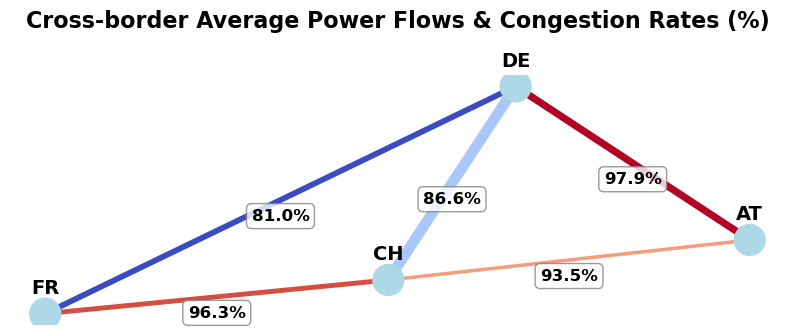

In [5]:
import matplotlib.pyplot as plt

n.buses.loc["DE", ["x", "y"]] = [10.45, 50.2] 
n.buses.loc["FR", ["x", "y"]] = [2.21, 46.22]
n.buses.loc["CH", ["x", "y"]] = [8.22, 46.81]
n.buses.loc["AT", ["x", "y"]] = [14.55, 47.51]

mean_flow = n.lines_t.p0.mean().abs() 
loading = (mean_flow / n.lines.s_nom) * 100 

fig, ax = plt.subplots(figsize=(10, 8))

n.plot(
    ax=ax,
    bus_sizes=0.08,                        
    bus_colors="lightblue",                
    line_colors=loading,                   
    line_cmap=plt.cm.coolwarm,             
    line_widths=mean_flow / 800,           
    title="Cross-border Average Power Flows & Congestion Rates (%)"
)

plt.title("Cross-border Average Power Flows & Congestion Rates (%)", 
          y=1.05, fontsize=16, fontweight='bold', pad=25)

y_offset_line_labels = -0.15 
for line_name, line in n.lines.iterrows():
    bus0 = n.buses.loc[line.bus0]
    bus1 = n.buses.loc[line.bus1]
    
    x_pos = (bus0.x + bus1.x) / 2
    y_pos = (bus0.y + bus1.y) / 2 + y_offset_line_labels 
    
    ax.text(x_pos, y_pos, f"{loading[line_name]:.1f}%", 
            fontsize=12, fontweight='bold', ha='center', va='top', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))
    
y_offset_bus_labels = 0.35 
for bus_name, bus in n.buses.iterrows():
    ax.text(bus.x, bus.y + y_offset_bus_labels, bus_name, 
            fontsize=14, fontweight='bold', ha='center')

ax.axis('off')



#plt.savefig("final_network_congestion_map.png", dpi=300, bbox_inches='tight')

plt.show()